# 91 — Distribution analyses

Inspect every processed layer that feeds `92_scoring.ipynb` — raw distribution shape, spread, outliers, and post-normalization footprint. The goal is to spot layers that will secretly dominate the composite score after min-max normalization because a few extreme cells compress everyone else into a narrow band, or that are so oddly shaped that the weight set in `weights.yaml` becomes meaningless.

No transformations are applied here — this is diagnostic-only.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common import load_layers, load_weights

## Load layers

Same set as the scoring notebook — every non-zero-weighted entry in `weights.yaml` whose `.nc` file exists on disk.

In [14]:
weights = load_weights()
layers = load_layers(weights)
print(f'loaded {len(layers)} of {len(weights)} layers')
list(layers)

loaded 21 of 21 layers


['sea_proximity',
 'terrain_ruggedness',
 'sun_hours',
 'temperature_pleasantness',
 'annual_greenness',
 'precipitation_balance',
 'climate_vulnerability',
 'natural_disaster_risk',
 'air_quality',
 'population_density',
 'urbanity',
 'internet_connectivity',
 'healthcare_access',
 'income',
 'cost_of_living',
 'crime_rate',
 'human_freedom',
 'corruption',
 'education',
 'people_happiness',
 'working_hours']

## Flatten

Drop ocean / NaN cells and reduce each layer to a 1-D array of finite values. Each layer keeps its own length because the NaN patterns differ (ocean masks, country-coverage gaps, polar-latitude cutoffs).

In [15]:
def flatten(da):
    """Return the layer's non-NaN values as a 1-D numpy array."""
    v = da.values.ravel()
    return v[np.isfinite(v)]

flat = {name: flatten(da) for name, da in layers.items()}
pd.Series({name: len(v) for name, v in flat.items()}, name='n_cells')

sea_proximity               68294
terrain_ruggedness          68280
sun_hours                   68260
temperature_pleasantness    68274
annual_greenness            65688
precipitation_balance       68274
climate_vulnerability       64843
natural_disaster_risk       66782
air_quality                 59406
population_density          68294
urbanity                    68294
internet_connectivity       30948
healthcare_access           68234
income                      68246
cost_of_living              68075
crime_rate                  64951
human_freedom               64956
corruption                  64956
education                   64595
people_happiness            64424
working_hours               65146
Name: n_cells, dtype: int64

## Summary stats

Standard descriptive stats plus skew and excess kurtosis. Rules of thumb: `|skew| > 1` means a clearly asymmetric distribution; `kurtosis_excess > 3` means a heavy tail relative to a normal distribution. Either flag means min-max normalization will not spread the layer symmetrically across `[0, 1]`.

In [16]:
def summarize(values):
    """Return descriptive stats + skew and excess kurtosis for a 1-D array."""
    s = pd.Series(values)
    q = np.quantile(values, [0.01, 0.25, 0.5, 0.75, 0.99])
    return {
        'n': len(values),
        'mean': values.mean(),
        'std': values.std(),
        'min': values.min(),
        'p1': q[0],
        'p25': q[1],
        'median': q[2],
        'p75': q[3],
        'p99': q[4],
        'max': values.max(),
        'skew': s.skew(),
        'kurtosis_excess': s.kurt(),
    }

stats_df = pd.DataFrame({name: summarize(v) for name, v in flat.items()}).T
stats_df.round(3)

,n,mean,std,min,p1,p25,median,p75,p99,max,skew,kurtosis_excess
sea_proximity,68294.0,-438.412,476.814,-2506.247,-1985.586,-687.843,-266.748,-49.941,-0.559,-0.001,-1.347,1.432
terrain_ruggedness,68280.0,136.366,190.766,0.000,2.873,24.147,60.565,175.831,943.297,2969.792,3.238,15.822
sun_hours,68260.0,1523.052,501.715,540.173,758.814,1036.709,1539.173,1947.238,2439.622,2654.745,0.108,-1.332
temperature_pleasantness,68274.0,0.182,0.169,0.000,0.000,0.014,0.170,0.288,0.694,0.971,0.886,0.750
annual_greenness,65688.0,0.373,0.240,-0.100,-0.046,0.175,0.353,0.565,0.835,0.897,0.173,-0.992
precipitation_balance,68274.0,0.284,0.213,0.000,0.000,0.111,0.255,0.435,0.773,0.893,0.482,-0.705
climate_vulnerability,64843.0,-0.378,0.093,-0.655,-0.638,-0.430,-0.355,-0.310,-0.282,-0.263,-1.056,0.324
natural_disaster_risk,66782.0,-0.583,0.182,-1.000,-0.929,-0.716,-0.593,-0.468,-0.123,-0.000,0.340,-0.375
air_quality,59406.0,-17.865,17.373,-263.536,-82.735,-25.816,-11.408,-5.372,-1.328,-0.800,-2.176,8.754
population_density,68294.0,0.365,0.446,0.000,0.000,0.000,0.000,1.000,1.000,1.000,0.542,-1.572


## Raw distributions

One histogram per layer on its own x-axis (raw units). Shape and skew are what matter here — absolute values differ by many orders of magnitude across layers.

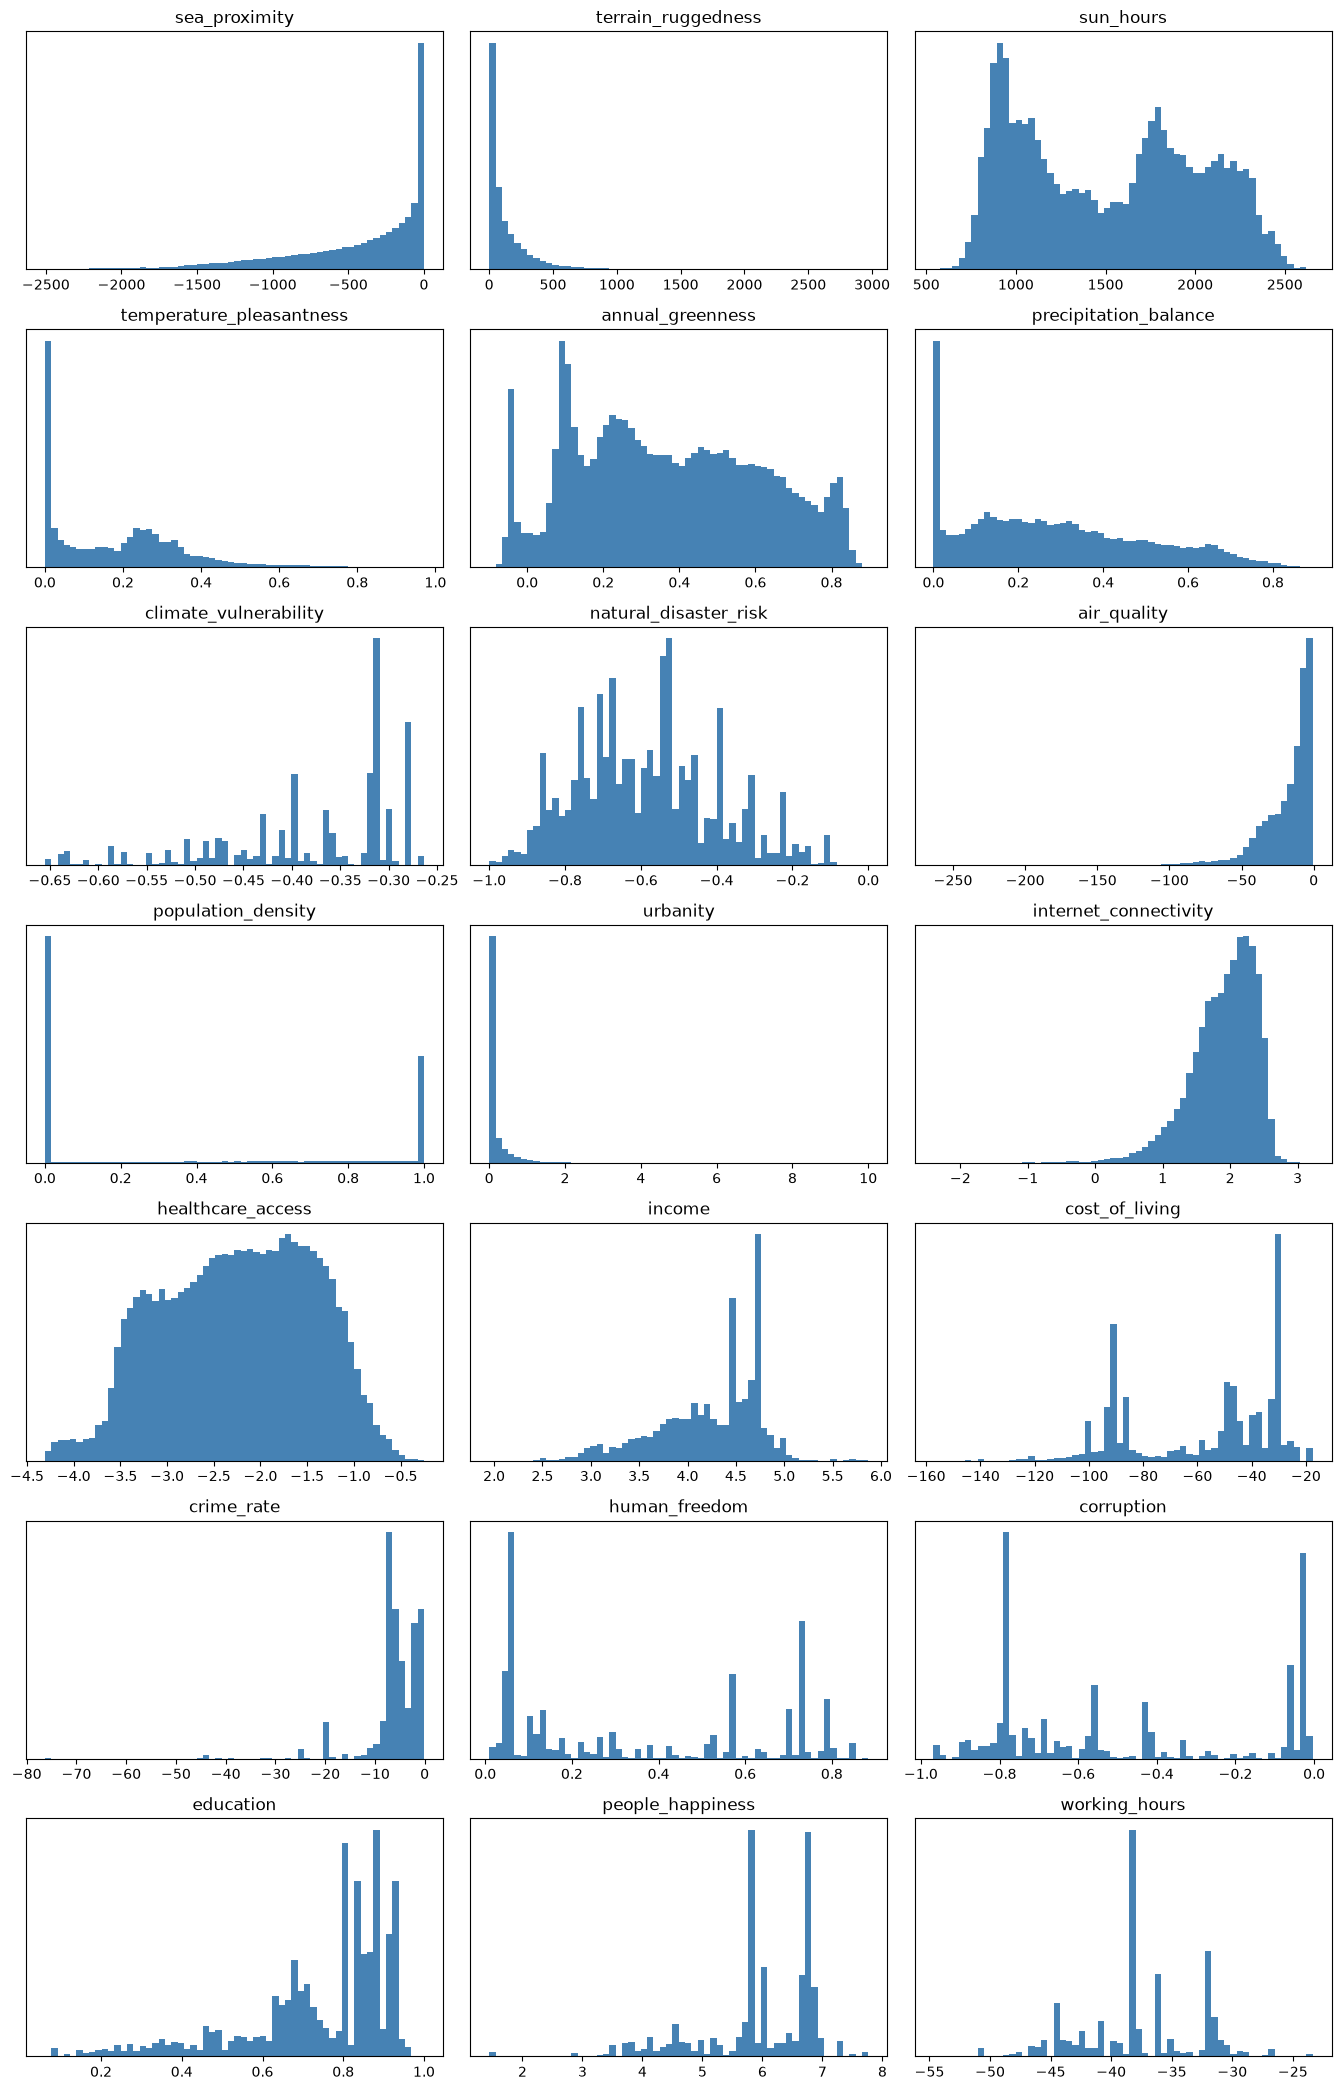

In [17]:
def grid(n, ncols=3, cell_size=(4.5, 3)):
    """Create a figure with `n` subplots laid out in `ncols` columns.

    Returns the figure and a flat list of axes; any extras beyond `n` are
    hidden by the caller.
    """
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * cell_size[0], nrows * cell_size[1]))
    axes = np.atleast_1d(axes).ravel().tolist()
    return fig, axes

fig, axes = grid(len(flat))
for ax, (name, values) in zip(axes, flat.items()):
    ax.hist(values, bins=60, color='steelblue', edgecolor='none')
    ax.set_title(name)
    ax.set_yticks([])
for ax in axes[len(flat):]:
    ax.set_visible(False)
fig.tight_layout()

## Post-normalization

Everything below uses the same min-max scaling that `92_scoring.ipynb` applies before summing. This is the state in which layers actually contribute to the composite score.

In [18]:
def minmax(values):
    """Min-max scale a 1-D array of finite values into `[0, 1]`."""
    lo, hi = values.min(), values.max()
    return (values - lo) / (hi - lo) if hi > lo else np.zeros_like(values)

norm = {name: minmax(v) for name, v in flat.items()}

/var/folders/hq/d3n2t3r135gfw07crm1cqnrh0000gn/T/ipykernel_43046/3368365686.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


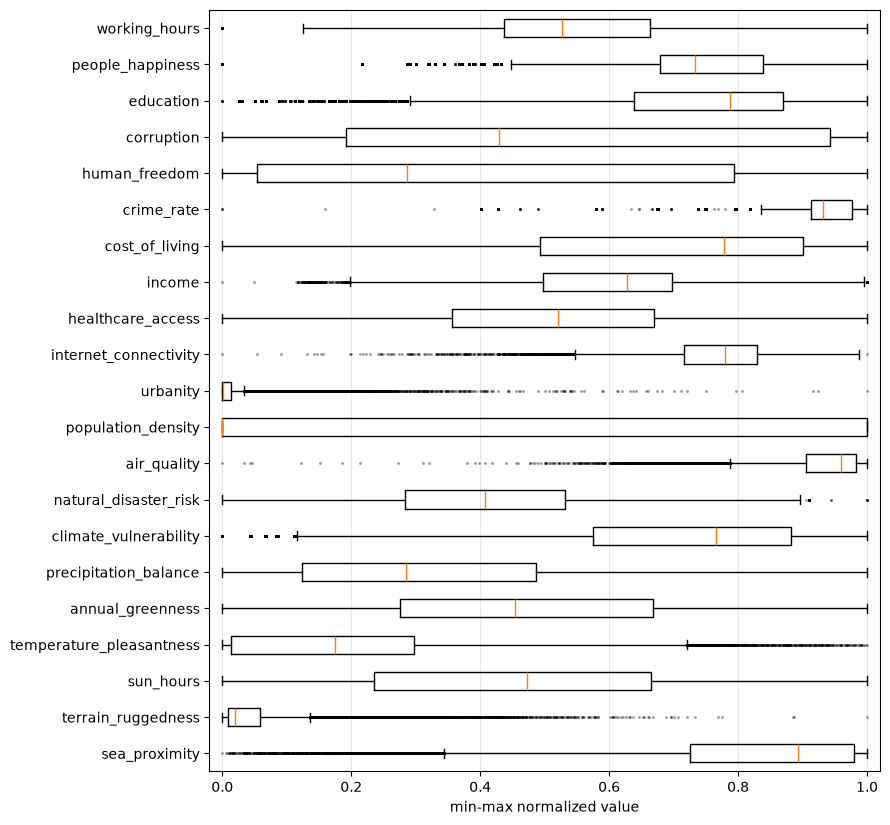

In [19]:
names = list(norm)
fig, ax = plt.subplots(figsize=(9, 0.35 * len(names) + 1))
ax.boxplot(
    [norm[n] for n in names],
    vert=False,
    showfliers=True,
    flierprops=dict(marker='.', markersize=2, alpha=0.4),
)
ax.set_yticks(range(1, len(names) + 1))
ax.set_yticklabels(names)
ax.set_xlim(-0.02, 1.02)
ax.set_xlabel('min-max normalized value')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()

## Variance contribution to an unweighted sum

`weights.yaml` currently gives every layer weight `1.0`. Under min-max normalization and an equal-weighted sum, each layer's contribution to the *variance* of the composite score is proportional to `var(normalized)` (ignoring cross-layer covariance). Layers with a larger post-normalization variance are effectively over-represented — the nominal weight of `1.0` means very different things across layers.

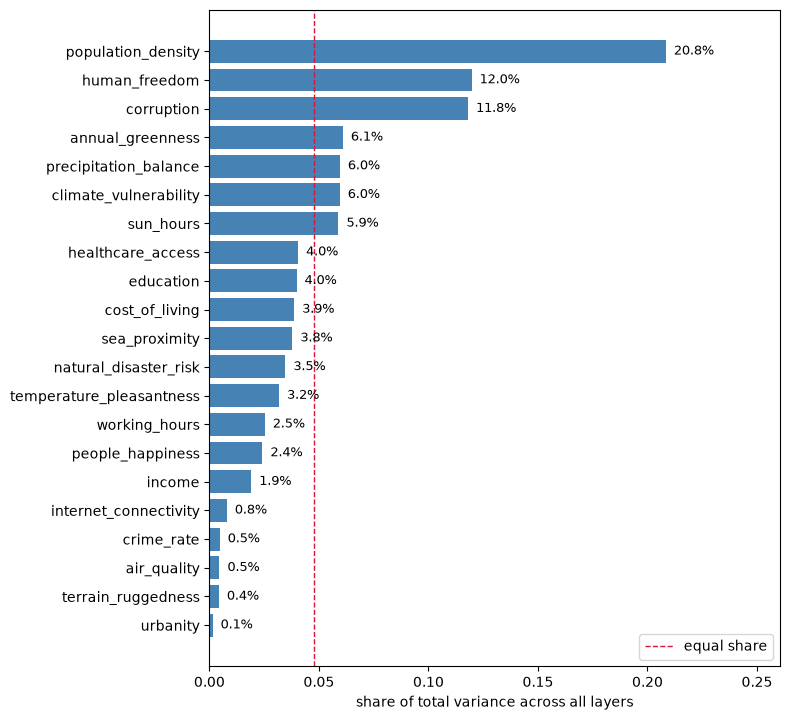

In [20]:
var = pd.Series({name: v.var() for name, v in norm.items()}).sort_values()
share = var / var.sum()

fig, ax = plt.subplots(figsize=(8, 0.3 * len(var) + 1))
ax.barh(share.index, share.values, color='steelblue')
ax.set_xlabel('share of total variance across all layers')
for i, v in enumerate(share.values):
    ax.text(v, i, f'  {v:.1%}', va='center', fontsize=9)
ax.set_xlim(0, share.max() * 1.25)
ax.axvline(1 / len(share), color='crimson', linestyle='--', linewidth=1, label='equal share')
ax.legend(loc='lower right')
fig.tight_layout()

## Outlier share

Two definitions:

- **3σ-outliers** — cells more than three standard deviations from the mean. Meaningful when the layer is roughly symmetric.
- **IQR-outliers (Tukey)** — cells outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. Robust to skew.

A layer with more than ~1% IQR outliers has a fat tail that will dominate min-max scaling.

In [21]:
def outlier_share(values):
    """Fraction of `values` flagged as outliers under 3σ and Tukey IQR rules."""
    mu, sd = values.mean(), values.std()
    sigma = np.abs(values - mu) > 3 * sd
    q1, q3 = np.quantile(values, [0.25, 0.75])
    iqr = q3 - q1
    tukey = (values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)
    return {'sigma_3_share': sigma.mean(), 'iqr_tukey_share': tukey.mean()}

outliers = pd.DataFrame({name: outlier_share(v) for name, v in flat.items()}).T
outliers.sort_values('iqr_tukey_share', ascending=False).round(4)

,sigma_3_share,iqr_tukey_share
urbanity,0.0190,0.1392
people_happiness,0.0071,0.0753
terrain_ruggedness,0.0223,0.0749
crime_rate,0.0148,0.0632
education,0.0122,0.0486
air_quality,0.0200,0.0354
climate_vulnerability,0.0000,0.0339
sea_proximity,0.0142,0.0256
internet_connectivity,0.0110,0.0203
temperature_pleasantness,0.0105,0.0094


## Correlations

If two layers carry strongly correlated signal, giving both a full weight in `weights.yaml` double-counts it. Correlations are computed pairwise-complete (each pair uses only the cells where both layers have a finite value), so country-coverage gaps in the Tier C layers don't drop the whole matrix.

Both Pearson (linear) and Spearman (rank-based) are shown side-by-side — Spearman is more honest for the heavily skewed Tier C layers, Pearson for the smoother Tier A grids. Big Spearman/Pearson gaps flag pairs where the raw relationship is nonlinear.

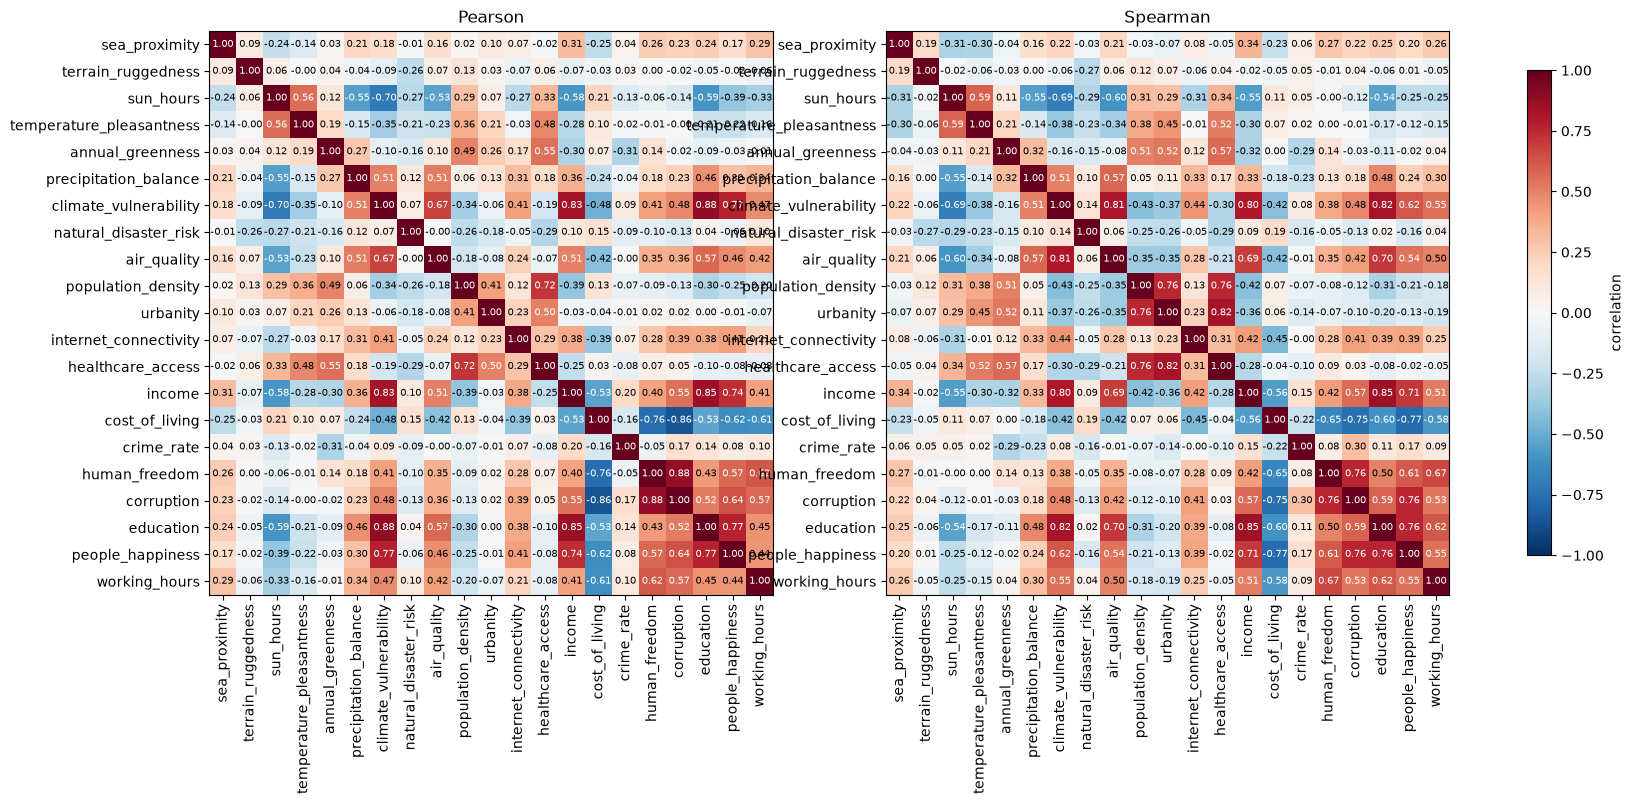

In [22]:
shapes = {name: da.shape for name, da in layers.items()}
assert len(set(shapes.values())) == 1, f'layers have different shapes: {shapes}'

df = pd.DataFrame({name: da.values.ravel() for name, da in layers.items()})
pearson = df.corr(method='pearson')
spearman = df.corr(method='spearman')


def plot_corr(matrix, ax, title):
    """Draw a correlation matrix as an annotated heatmap on `ax`."""
    im = ax.imshow(matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(matrix)))
    ax.set_yticks(range(len(matrix)))
    ax.set_xticklabels(matrix.columns, rotation=90)
    ax.set_yticklabels(matrix.index)
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            v = matrix.iat[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(v) > 0.5 else 'black')
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 2, figsize=(20, 9))
plot_corr(pearson, axes[0], 'Pearson')
im = plot_corr(spearman, axes[1], 'Spearman')
fig.colorbar(im, ax=axes, shrink=0.7, label='correlation')

In [23]:
def top_pairs(matrix, k=15):
    """Return the `k` variable pairs with the largest absolute correlation."""
    mask = np.triu(np.ones(matrix.shape, dtype=bool), k=1)
    upper = matrix.where(mask)
    pairs = upper.stack().rename('r').reset_index()
    pairs.columns = ['a', 'b', 'r']
    pairs['abs_r'] = pairs['r'].abs()
    return pairs.sort_values('abs_r', ascending=False).head(k).drop(columns='abs_r').reset_index(drop=True)


top_pairs(spearman, k=15).round(2)

,a,b,r
0,income,education,0.85
1,urbanity,healthcare_access,0.82
2,climate_vulnerability,education,0.82
3,climate_vulnerability,air_quality,0.81
4,climate_vulnerability,income,0.80
5,cost_of_living,people_happiness,-0.77
6,education,people_happiness,0.76
7,human_freedom,corruption,0.76
8,corruption,people_happiness,0.76
9,population_density,healthcare_access,0.76


## Derive weights from correlations

Turn the Spearman matrix above into a per-variable weight using **mean-|ρ| shrinkage**:

`weight_i = 1 − mean_{j≠i} |ρ_ij|`

A layer that averages |ρ|=0 with everything else keeps weight 1; a layer that averages |ρ|=0.5 across the other 20 layers drops to ~0.5. This spreads the redundancy penalty across all correlated partners instead of picking a single "primary" variable per cluster. Spearman is used (not Pearson) for the same reason as the matrix above — it's more honest for the skewed Tier C layers.

The second code cell writes the derived values back to `weights.yaml`, preserving the header comment. Re-running the notebook re-syncs the file, so any manual edits to `weights.yaml` will be overwritten.

In [ ]:
mask = ~np.eye(len(spearman), dtype=bool)
mean_abs_r = spearman.abs().where(mask).mean(axis=1)
derived = (1 - mean_abs_r).round(2).reindex(list(weights))
assert derived.notna().all(), 'NaN in derived weights — check the correlation matrix'

comparison = pd.DataFrame({
    'current_weight': pd.Series(weights),
    'derived_weight': derived,
})
comparison['delta'] = (comparison['derived_weight'] - comparison['current_weight']).round(2)
comparison.sort_values('derived_weight')

In [ ]:
from common import save_weights

save_weights(derived.to_dict())
print(f'wrote {len(derived)} weights to weights.yaml')

## What to look for

- Layers at the top of the variance-contribution chart dominate the composite score at their current yaml weight. If that isn't intended, they need a log / robust transform *before* normalization (see the *Scaling* section of `DATASETS.md`), or a smaller yaml weight to compensate.
- Layers at the bottom of the chart barely move the score no matter what weight they receive.
- Layers with `|skew| > 1` or `kurtosis_excess > 3` in the stats table — typically also the top rows of the IQR-outlier table — are the candidates for those transforms.
- Pairs with `|r| > ~0.7` in the correlation matrices are double-counting each other under an equal-weight sum. `DATASETS.md` already flags `urbanity` vs. `population_density` and `sun_hours` vs. `temperature_pleasantness` as suspects; the country-level Tier C layers (`income`, `cost_of_living`, `human_freedom`, `corruption`, `climate_vulnerability`) are also expected to co-move because they share the same country-plateau structure.
- Country-level Tier C layers are naturally multimodal — one plateau per country. Expect boxy histograms rather than smooth bell curves; that isn't a bug, but it does mean skew / kurtosis alone don't fully describe them.